In [37]:
#Select any real-world dataset of your choice and study the data properly. Choose suitable input features and target variables for both classification and regression problems. Apply the first four machine learning algorithms taught in class to both problems. Perform the required data preprocessing, train and test the models, compare their results using suitable evaluation measures, and find which algorithm gives the best performance for classification and regression.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

df=pd.read_csv('Car data.csv')
df.head()
df.info()
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               21 non-null     str    
 1   Min Price (Lakh)   21 non-null     float64
 2   Max Price (Lakh)   21 non-null     float64
 3   Range (kmpl)       21 non-null     float64
 4   CC                 21 non-null     int64  
 5   Seats              21 non-null     int64  
 6   Variants           21 non-null     int64  
 7   Type               21 non-null     str    
 8   Ex-Showroom Price  21 non-null     int64  
 9   RTO                21 non-null     float64
 10  Insurance          21 non-null     float64
 11  Other              21 non-null     int64  
 12  Onroad Price       21 non-null     str    
dtypes: float64(5), int64(5), str(3)
memory usage: 2.3 KB


,Min Price (Lakh),Max Price (Lakh),Range (kmpl),CC,Seats,Variants,Ex-Showroom Price,RTO,Insurance,Other
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,2.100000e+01,2.100000e+01,21.000000,21.000000
mean,15.129048,42.762857,17.781429,1690.857143,5.571429,22.190476,2.639533e+06,2.894617e+05,116669.697905,25116.952381
std,19.837477,77.051152,3.886819,536.710377,1.075706,21.404717,5.187114e+06,6.419840e+05,205833.811082,52708.566299
min,2.360000,9.600000,9.200000,1197.000000,4.000000,2.000000,6.128000e+05,4.290300e+04,25916.000000,0.000000
25%,7.490000,13.030000,16.000000,1199.000000,5.000000,9.000000,7.515000e+05,5.340500e+04,33850.000000,4500.000000
50%,9.790000,17.420000,17.440000,1497.000000,5.000000,19.000000,1.089900e+06,1.089900e+05,42196.000000,11599.000000
75%,13.850000,26.040000,20.090000,1997.000000,7.000000,26.000000,1.430000e+06,1.750000e+05,85943.000000,17719.000000
max,97.000000,285.000000,24.800000,2997.000000,8.000000,100.000000,2.360000e+07,2.950000e+06,939295.000000,236000.000000


In [39]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [40]:
df=df.drop_duplicates()
df.dropna()

,Name,Min Price (Lakh),Max Price (Lakh),Range (kmpl),CC,Seats,Variants,Type,Ex-Showroom Price,RTO,Insurance,Other,Onroad Price
0,Mahindra Thar,11.35,17.60,15.20,1497,4,19,Petrol,1430000,143000.0,84367.000,14300,"16,71,667"
1,Maruti Swift,6.49,9.60,24.80,1197,5,11,Petrol,649000,46240.0,27791.000,5485,"7,28,516"
2,Mahindra Scorpio,13.62,17.42,22.00,2184,7,4,Diesel,1361600,175000.0,85943.000,27532,"16,50,075"
3,Tata Punch,6.13,10.20,20.09,1199,5,25,Petrol,612900,42903.0,35311.000,0,"6,91,114"
4,Hyundai Creta,11.00,20.15,17.40,1497,5,28,Petrol,1099900,116863.0,45300.000,11599,"12,73,662"
5,Mahindra XUV700,13.99,26.04,15.00,1999,5,49,Petrol,1399000,139900.0,83172.000,13990,"16,36,062"
6,Tata Nexon,8.00,15.80,17.44,1199,5,100,Petrol,799990,55999.0,42196.000,0,"8,98,185"
7,Maruti Brezza,8.34,14.14,17.38,1462,5,15,Petrol,834000,59210.0,33849.000,5485,"9,32,544"
8,Mahindra XUV 3XO,7.49,15.49,18.89,1197,5,25,Petrol,749000,52430.0,40320.000,0,"8,41,750"
9,Toyota Fortuner,33.43,51.44,10.00,2694,7,7,Petrol,3343000,334300.0,166175.000,33830,"38,77,305"


In [41]:
#select X and Y
x=df[["Ex-Showroom Price"]]
y=df[["Onroad Price"]]

In [42]:
#split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [43]:
#linear regression
model = LinearRegression()

# Clean the target values before training (remove Indian-style commas)
y_train = y_train.replace(r',', '', regex=True).astype(float)
y_test = y_test.replace(r',', '', regex=True).astype(float)

# Fit the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Regression Evaluation
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE : 9348.463110292283
MSE : 121647059.82603343
RMSE: 11029.3725943969
R2 Score: 0.999110365967997


In [45]:
#CLASSIFICATION
df.columns
# The dataset uses "Type" instead of "Fuel Type"
df["Fuel Type"] = (
    df["Type"]
    .astype(str)
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

df["Fuel Type"].value_counts()



Fuel Type
Petrol    16
Diesel     5
Name: count, dtype: int64

In [46]:
#Select Classification X and y
X = df[[
    "Ex-Showroom Price",
    "Onroad Price"
]]

y = df["Fuel Type"]

In [47]:
#Encode Target
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [48]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
#Feature Scaling
scaler = StandardScaler()

# Remove Indian-style commas and convert both features to numeric values
X_train = X_train.replace(",", "", regex=True).astype(float)
X_test = X_test.replace(",", "", regex=True).astype(float)

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [50]:
#Logistic Regression

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Logistic Regression Evaluation
print("LOGISTIC REGRESSION")

print("Accuracy :", accuracy_score(y_test, logistic_pred))

print("Precision:",
precision_score(y_test, logistic_pred, average="weighted"))

print("Recall   :",
recall_score(y_test, logistic_pred, average="weighted"))

print("F1 Score :",
f1_score(y_test, logistic_pred, average="weighted"))

LOGISTIC REGRESSION
Accuracy : 0.8
Precision: 0.64
Recall   : 0.8
F1 Score : 0.711111111111111


c:\Users\siddh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


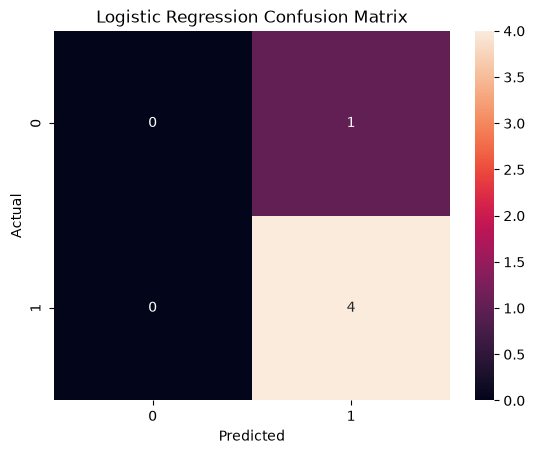

In [52]:
from sklearn.metrics import confusion_matrix

#Logistic Regression Confusion Matrix
cm = confusion_matrix(y_test, logistic_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [53]:
#Naive Bayes
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [54]:
#Naive Bayes Evaluation
print("NAIVE BAYES")

print("Accuracy :", accuracy_score(y_test, nb_pred))

print("Precision:",
precision_score(y_test, nb_pred, average="weighted"))

print("Recall   :",
recall_score(y_test, nb_pred, average="weighted"))

print("F1 Score :",
f1_score(y_test, nb_pred, average="weighted"))

NAIVE BAYES
Accuracy : 0.6
Precision: 0.6
Recall   : 0.6
F1 Score : 0.6


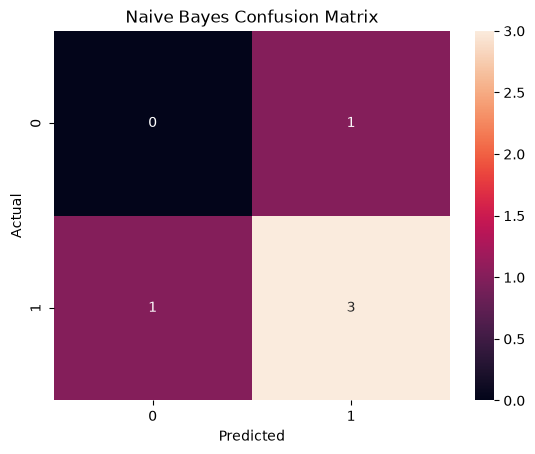

In [55]:
#Naive Bayes Confusion Matrix
cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [56]:
#Classification Comparison
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(
    y_test, logistic_pred, average="weighted"
)
logistic_recall = recall_score(
    y_test, logistic_pred, average="weighted"
)
logistic_f1 = f1_score(
    y_test, logistic_pred, average="weighted"
)

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(
    y_test, nb_pred, average="weighted"
)
nb_recall = recall_score(
    y_test, nb_pred, average="weighted"
)
nb_f1 = f1_score(
    y_test, nb_pred, average="weighted"
)

results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy
    ],
    "Precision": [
        logistic_precision,
        nb_precision
    ],
    "Recall": [
        logistic_recall,
        nb_recall
    ],
    "F1 Score": [
        logistic_f1,
        nb_f1
    ]
})

results

c:\Users\siddh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8,0.64,0.8,0.711111
1,Naive Bayes,0.6,0.60,0.6,0.600000


In [57]:
#Find Best Classification Algorithm
best_model = results.loc[
    results["F1 Score"].idxmax()
]

best_model

Algorithm    Logistic Regression
Accuracy                     0.8
Precision                   0.64
Recall                       0.8
F1 Score                0.711111
Name: 0, dtype: object